In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import pipeline
import warnings
warnings.filterwarnings("ignore")

c:\Users\ivank\OneDrive\Escritorio\Final\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv('Hola.txt', sep=',')

In [3]:
df.head()

,id,frase,agresividad,manipulacion,sarcasmo
0,1,es que yo soy diferente al resto de los hombres,0.2,0.7,0.1
1,2,Es que a mi nadie me da pelota yo siempre soy ...,0.2,0.9,0.1
2,3,todo lo malo que le pasa es tu culpa,0.9,0.8,0.0
3,4,¿Le estás enviando mensajes a esa chica coquet...,0.3,0.6,0.2
4,5,¿Qué? ¿No puedo hablar con mis amigos?!,0.7,0.5,0.4


In [4]:
data = {
    "id": [1, 2, 3, 4, 5, 6, 7, 8],
    "frase": [
        "es que yo soy diferente al resto de los hombres",
        "nunca vas a lograr nada en la vida",
        "claro que me importa, como no",
        "te digo una cosa y haces otra, eres un desastre",
        "me encanta pasar las tardes contigo",
        "si me dejas, me mato, es tu culpa",
        "qué bonito detalle, gracias por la basura",
        "no te preocupes, todo estará bien"
    ],
    "agresividad": [0.2, 0.9, 0.1, 0.7, 0.0, 0.8, 0.4, 0.0],
    "manipulacion": [0.7, 0.3, 0.4, 0.2, 0.0, 0.9, 0.1, 0.0],
    "sarcasmo": [0.1, 0.0, 0.9, 0.1, 0.0, 0.2, 0.8, 0.0]
}
df = pd.DataFrame(data)

# Mostrar los primeros datos
print(f"Total de frases: {len(df)}")
df.head()

Total de frases: 8


,id,frase,agresividad,manipulacion,sarcasmo
0,1,es que yo soy diferente al resto de los hombres,0.2,0.7,0.1
1,2,nunca vas a lograr nada en la vida,0.9,0.3,0.0
2,3,"claro que me importa, como no",0.1,0.4,0.9
3,4,"te digo una cosa y haces otra, eres un desastre",0.7,0.2,0.1
4,5,me encanta pasar las tardes contigo,0.0,0.0,0.0


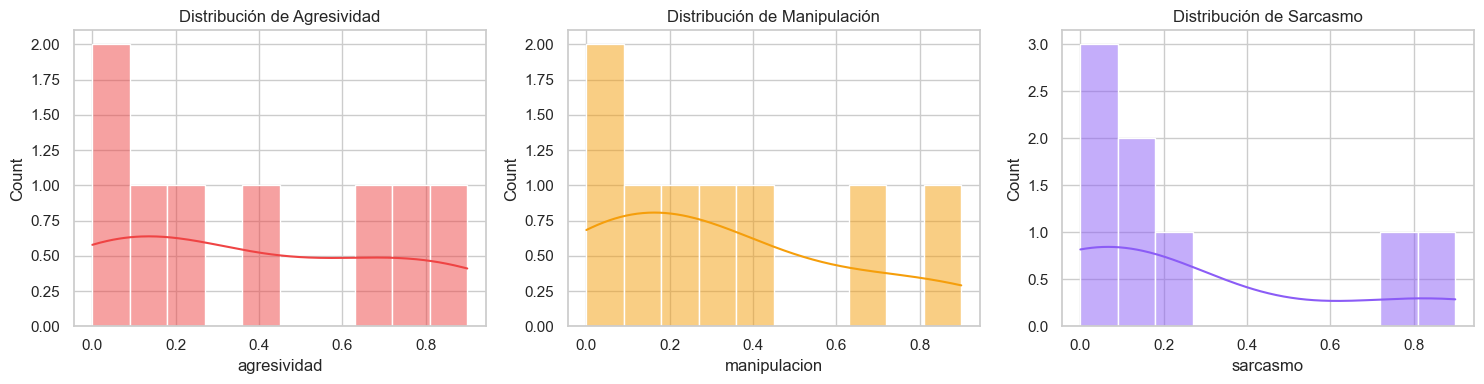

,agresividad,manipulacion,sarcasmo
count,8.000000,8.000000,8.000000
mean,0.387500,0.325000,0.262500
std,0.368152,0.328416,0.370087
min,0.000000,0.000000,0.000000
25%,0.075000,0.075000,0.000000
50%,0.300000,0.250000,0.100000
75%,0.725000,0.475000,0.350000
max,0.900000,0.900000,0.900000


In [5]:
# Configurar estilo bonito
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Histogramas
sns.histplot(df['agresividad'], bins=10, kde=True, ax=axes[0], color="#ef4444")
axes[0].set_title("Distribución de Agresividad")

sns.histplot(df['manipulacion'], bins=10, kde=True, ax=axes[1], color="#f59e0b")
axes[1].set_title("Distribución de Manipulación")

sns.histplot(df['sarcasmo'], bins=10, kde=True, ax=axes[2], color="#8b5cf6")
axes[2].set_title("Distribución de Sarcasmo")

plt.tight_layout()
plt.show()

# Estadísticas descriptivas
df[['agresividad', 'manipulacion', 'sarcasmo']].describe()

In [6]:
import torch

In [7]:
print("Cargando modelos (puede tardar un minuto la primera vez)...")
print("-" * 50)

# 1. Sentimiento (español)
sentiment_analyzer = pipeline(
    "text-classification", 
    model="UMUTeam/roberta-spanish-sentiment-analysis", 
    top_k=1
)
print("✅ Modelo de Sentimiento cargado")

# 2. Toxicidad - Modelo público alternativo

toxicity_analyzer = pipeline(
    "text-classification", 
    model="unitary/toxic-bert",
    top_k=1
)
print("✅ Modelo de Toxicidad cargado (unitary/toxic-bert)")

# 3. Sarcasmo/Ironía (modelo en español)
sarcasm_analyzer = pipeline(
    "text-classification", 
    model="l52mas/ironiaL52_roberta", 
    top_k=1
)
print("✅ Modelo de Sarcasmo cargado")
print("-" * 50)

test_texts = [
    "¡Qué bonito día!",
    "Eres un genio",
    "Me encanta madrugar los lunes"
]

Cargando modelos (puede tardar un minuto la primera vez)...
--------------------------------------------------


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 9781.81it/s]


✅ Modelo de Sentimiento cargado


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 8876.51it/s]
BertForSequenceClassification LOAD REPORT from: unitary/toxic-bert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Modelo de Toxicidad cargado (unitary/toxic-bert)


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 9226.42it/s]


✅ Modelo de Sarcasmo cargado
--------------------------------------------------


In [8]:
def get_result(analyzer, text):
    """Función auxiliar para extraer resultados de forma consistente"""
    result = analyzer(text)
    if isinstance(result, list) and len(result) > 0:
        item = result[0]
        if isinstance(item, dict):
            return f"{item.get('label', 'N/A')} ({item.get('score', 0):.3f})"
        return str(item)
    return str(result)

print("\n🔍 Prueba de los modelos:")
for text in test_texts:
    print(f"\n📝 Texto: '{text}'")
    print(f"   Sentimiento: {get_result(sentiment_analyzer, text)}")
    print(f"   Toxicidad: {get_result(toxicity_analyzer, text)}")
    print(f"   Sarcasmo: {get_result(sarcasm_analyzer, text)}")


🔍 Prueba de los modelos:

📝 Texto: '¡Qué bonito día!'
   Sentimiento: [{'label': 'positive', 'score': 0.9975753426551819}]
   Toxicidad: [{'label': 'toxic', 'score': 0.026844626292586327}]
   Sarcasmo: [{'label': 'non_irony', 'score': 0.9989472031593323}]

📝 Texto: 'Eres un genio'
   Sentimiento: [{'label': 'positive', 'score': 0.9966879487037659}]
   Toxicidad: [{'label': 'toxic', 'score': 0.060217514634132385}]
   Sarcasmo: [{'label': 'non_irony', 'score': 0.9645141363143921}]

📝 Texto: 'Me encanta madrugar los lunes'
   Sentimiento: [{'label': 'positive', 'score': 0.99683678150177}]
   Toxicidad: [{'label': 'toxic', 'score': 0.0689757913351059}]
   Sarcasmo: [{'label': 'non_irony', 'score': 0.9202099442481995}]


In [9]:
def extraer_score_negativo(resultado, etiqueta_negativa):
    """
    Los modelos devuelven [{'label': 'NEG', 'score': 0.95}]
    Esta función busca la etiqueta negativa y devuelve su probabilidad.
    Si la etiqueta negativa no está, devuelve (1 - probabilidad de la positiva).
    """
    if not resultado:
        return 0.0
    
    label = resultado[0]['label'].upper()
    score = resultado[0]['score']
    
    # Normalizar nombres de etiquetas
    if etiqueta_negativa.upper() in label or 'NEG' in label or 'TOXIC' in label or 'IRONIA' in label:
        return score
    else:
        return 1.0 - score

def analizar_frase(texto):
    """Ejecuta los 3 modelos y devuelve los scores normalizados de 0 a 1"""
    try:
        sent = sentiment_analyzer(texto)[0]
        tox = toxicity_analyzer(texto)[0]
        sar = sarcasm_analyzer(texto)[0]
        
        return {
            "pred_agresividad": extraer_score_negativo(tox, "TOXIC"),
            "pred_manipulacion": extraer_score_negativo(sent, "NEG"), # Proxy
            "pred_sarcasmo": extraer_score_negativo(sar, "IRONIA")
        }
    except Exception as e:
        return {"pred_agresividad": 0, "pred_manipulacion": 0, "pred_sarcasmo": 0}

In [10]:
print("Analizando frases con los modelos...")
predicciones = df['frase'].apply(analizar_frase)
df_pred = pd.DataFrame(predicciones.tolist())

# Unir con el dataframe original
df_completo = pd.concat([df, df_pred], axis=1)

# Mostrar comparativa lado a lado
columnas_mostrar = ['frase', 'agresividad', 'pred_agresividad', 'sarcasmo', 'pred_sarcasmo']
df_completo[columnas_mostrar].head(10)

Analizando frases con los modelos...


,frase,agresividad,pred_agresividad,sarcasmo,pred_sarcasmo
0,es que yo soy diferente al resto de los hombres,0.2,0.027096,0.1,0.007154
1,nunca vas a lograr nada en la vida,0.9,0.015961,0.0,0.044528
2,"claro que me importa, como no",0.1,0.003764,0.9,0.000701
3,"te digo una cosa y haces otra, eres un desastre",0.7,0.182804,0.1,0.034490
4,me encanta pasar las tardes contigo,0.0,0.303352,0.0,0.078730
5,"si me dejas, me mato, es tu culpa",0.8,0.044832,0.2,0.037391
6,"qué bonito detalle, gracias por la basura",0.4,0.007156,0.8,0.028117
7,"no te preocupes, todo estará bien",0.0,0.044945,0.0,0.031420


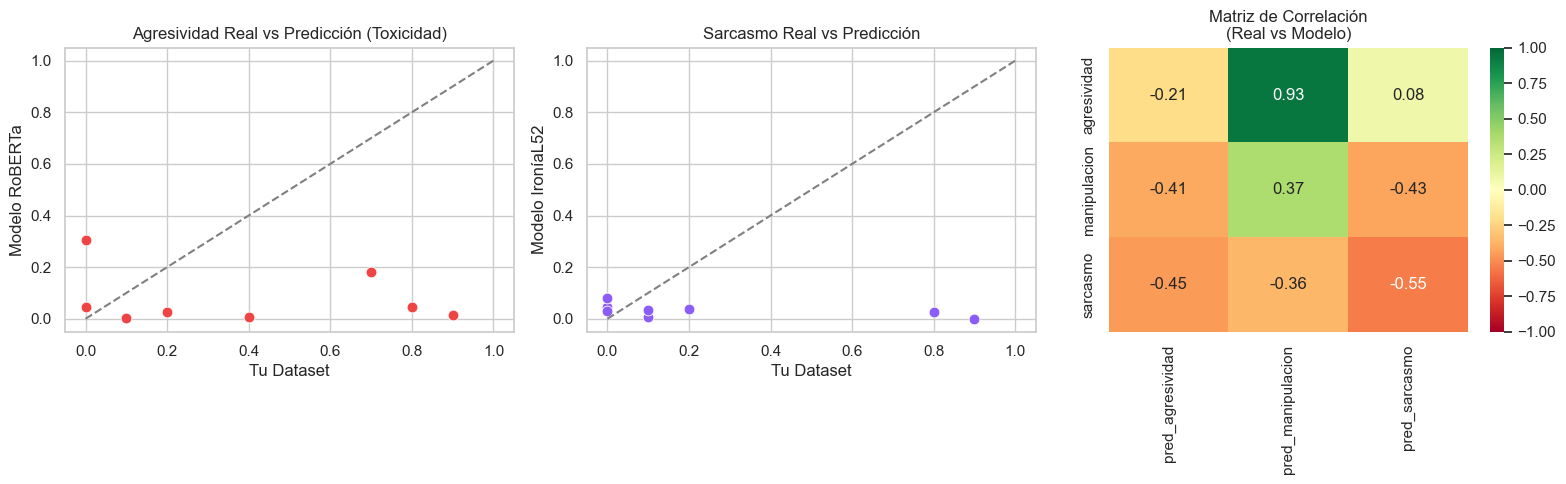

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Agresividad vs Toxicidad del modelo
sns.scatterplot(data=df_completo, x='agresividad', y='pred_agresividad', ax=axes[0], color="#ef4444", s=60)
axes[0].plot([0, 1], [0, 1], color='gray', linestyle='--') # Línea perfecta
axes[0].set_title("Agresividad Real vs Predicción (Toxicidad)")
axes[0].set_xlabel("Tu Dataset")
axes[0].set_ylabel("Modelo RoBERTa")

# 2. Sarcasmo
sns.scatterplot(data=df_completo, x='sarcasmo', y='pred_sarcasmo', ax=axes[1], color="#8b5cf6", s=60)
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--')
axes[1].set_title("Sarcasmo Real vs Predicción")
axes[1].set_xlabel("Tu Dataset")
axes[1].set_ylabel("Modelo IroníaL52")

# 3. Correlación general
cols = ['agresividad', 'manipulacion', 'sarcasmo', 'pred_agresividad', 'pred_manipulacion', 'pred_sarcasmo']
corr = df_completo[cols].corr()
# Filtrar solo las cruzadas (real vs pred)
cruzadas = corr.loc[['agresividad', 'manipulacion', 'sarcasmo'], ['pred_agresividad', 'pred_manipulacion', 'pred_sarcasmo']]
sns.heatmap(cruzadas, annot=True, cmap="RdYlGn", vmin=-1, vmax=1, ax=axes[2], fmt=".2f")
axes[2].set_title("Matriz de Correlación\n(Real vs Modelo)")

plt.tight_layout()
plt.show()

In [12]:
print("🔥 TOP 5 FRASES MÁS AGRESIVAS (Según tu dataset vs el Modelo)")
print("-" * 80)
top_agg = df_completo.nlargest(5, 'agresividad')[['frase', 'agresividad', 'pred_agresividad']]
print(top_agg.to_string(index=False))

print("\n🗣️ TOP 5 FRASES MÁS SARCÁSTICAS (Según tu dataset vs el Modelo)")
print("-" * 80)
top_sar = df_completo.nlargest(5, 'sarcasmo')[['frase', 'sarcasmo', 'pred_sarcasmo']]
print(top_sar.to_string(index=False))

🔥 TOP 5 FRASES MÁS AGRESIVAS (Según tu dataset vs el Modelo)
--------------------------------------------------------------------------------
                                          frase  agresividad  pred_agresividad
             nunca vas a lograr nada en la vida          0.9          0.015961
              si me dejas, me mato, es tu culpa          0.8          0.044832
te digo una cosa y haces otra, eres un desastre          0.7          0.182804
      qué bonito detalle, gracias por la basura          0.4          0.007156
es que yo soy diferente al resto de los hombres          0.2          0.027096

🗣️ TOP 5 FRASES MÁS SARCÁSTICAS (Según tu dataset vs el Modelo)
--------------------------------------------------------------------------------
                                          frase  sarcasmo  pred_sarcasmo
                  claro que me importa, como no       0.9       0.000701
      qué bonito detalle, gracias por la basura       0.8       0.028117
              si me

In [13]:
import pandas as pd
import numpy as np
import torch
from datasets import Dataset
from transformers import (
    AutoTokenizer, 
    AutoModelForSequenceClassification,
    TrainingArguments, 
    Trainer,
    RobertaPreTrainedModel,
    RobertaModel
)
import torch.nn as nn

# --- OPCIÓN A: Usar tus datos reales ---
# from google.colab import files
# uploaded = files.upload()
# df = pd.read_csv(list(uploaded.keys())[0])

# --- OPCIÓN B: Usar tus datos de ejemplo ---
data = {
    "id": [1, 2, 3, 4, 5],
    "frase": [
        "es que yo soy diferente al resto de los hombres",
        "Es que a mi nadie me da pelota yo siempre soy el elegido",
        "todo lo malo que le pasa es tu culpa",
        "¿Le estás enviando mensajes a esa chica coqueta?",
        "¿Qué? ¿No puedo hablar con mis amigos?!"
    ],
    "agresividad": [0.2, 0.2, 0.9, 0.3, 0.7],
    "manipulacion": [0.7, 0.9, 0.8, 0.6, 0.5],
    "sarcasmo": [0.1, 0.1, 0.0, 0.2, 0.4]
}
df = pd.DataFrame(data)

# Convertir a formato Hugging Face Dataset
# Nos aseguramos de que las etiquetas sean listas de floats
df["labels"] = df.apply(lambda x: [x["agresividad"], x["manipulacion"], x["sarcasmo"]], axis=1)
dataset = Dataset.from_pandas(df[["frase", "labels"]])

print("Dataset listo:")
print(dataset[0])

Dataset listo:
{'frase': 'es que yo soy diferente al resto de los hombres', 'labels': [0.2, 0.7, 0.1]}


In [6]:
import torch
import torch.nn as nn
from transformers import AutoTokenizer, RobertaModel, RobertaPreTrainedModel
import pandas as pd

# Verificar que las librerías están instaladas
try:
    import sentencepiece
    import protobuf
    print("✓ Dependencias necesarias instaladas correctamente")
except ImportError as e:
    print(f"✗ Error: Falta instalar {e.name}")
    print("Ejecuta: pip install sentencepiece protobuf")

class RoBERTaMultiTaskRegression(RobertaPreTrainedModel):
    def __init__(self, config):
        super().__init__(config)
        # Cargamos el cuerpo base de RoBERTa
        self.roberta = RobertaModel(config)
        # Una capa de dropout para evitar sobreajuste
        self.dropout = nn.Dropout(config.hidden_dropout_prob)
        # Nuestra capa final personalizada: 3 salidas (agresividad, manipulacion, sarcasmo)
        self.regressor = nn.Linear(config.hidden_size, 3)
        # Función Sigmoid para asegurar que las salidas siempre estén entre 0.0 y 1.0
        self.sigmoid = nn.Sigmoid()

    def forward(self, input_ids=None, attention_mask=None, labels=None):
        # Pasamos el texto por RoBERTa
        outputs = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        # Tomamos la representación oculta del token [CLS]
        pooled_output = outputs.pooler_output
        pooled_output = self.dropout(pooled_output)
        # Pasamos por nuestra capa de 3 neuronas
        logits = self.regressor(pooled_output)
        # Aplicamos Sigmoid para que los resultados sean de 0 a 1
        scores = self.sigmoid(logits)

        loss = None
        if labels is not None:
            # Usamos Error Cuadrático Medio (MSE) porque es regresión
            loss_fct = nn.MSELoss()
            loss = loss_fct(scores, labels.float())

        # El Trainer espera un diccionario con "loss" y "logits"
        return {"loss": loss, "logits": scores}

# Cargar el tokenizer y nuestro modelo personalizado basado en RoBERTa en español
model_name = "PlanTL-GOB-ES/roberta-base-bne"
print(f"Cargando tokenizer desde {model_name}...")

try:
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    print("✓ Tokenizer cargado exitosamente")
    
    # Inicializar el modelo
    print("Cargando modelo...")
    model = RoBERTaMultiTaskRegression.from_pretrained(model_name)
    print("✓ Modelo cargado exitosamente")
    
except Exception as e:
    print(f"Error al cargar el modelo: {e}")
    print("\nSoluciones posibles:")
    print("1. pip install sentencepiece protobuf")
    print("2. pip install --upgrade transformers")
    print("3. Si usas Jupyter, reinicia el kernel después de instalar")

c:\Users\ivank\OneDrive\Escritorio\Final\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✗ Error: Falta instalar protobuf
Ejecuta: pip install sentencepiece protobuf
Cargando tokenizer desde PlanTL-GOB-ES/roberta-base-bne...


Error al cargar el modelo: Couldn't instantiate the backend tokenizer from one of: 
(1) a `tokenizers` library serialization file, 
(2) a slow tokenizer instance to convert or 
(3) an equivalent slow tokenizer class to instantiate and convert. 
You need to have sentencepiece or tiktoken installed to convert a slow tokenizer to a fast one.

Soluciones posibles:
1. pip install sentencepiece protobuf
2. pip install --upgrade transformers
3. Si usas Jupyter, reinicia el kernel después de instalar


### Prueba de modelo

In [17]:
pip install sklearn

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'error'
Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [15 lines of output]
      The 'sklearn' PyPI package is deprecated, use 'scikit-learn'
      rather than 'sklearn' for pip commands.
      
      Here is how to fix this error in the main use cases:
      - use 'pip install scikit-learn' rather than 'pip install sklearn'
      - replace 'sklearn' by 'scikit-learn' in your pip requirements files
        (requirements.txt, setup.py, setup.cfg, Pipfile, etc ...)
      - if the 'sklearn' package is used by one of your dependencies,
        it would be great if you take some time to track which package uses
        'sklearn' instead of 'scikit-learn' and report it to their issue tracker
      - as a last resort, set the environment variable
        SKLEARN_ALLOW_DEPRECATED_SKLEARN_PACKAGE_INSTALL=True to avoid this error
      
      More information is available at
      https://github.com/scikit-learn/sklearn-

In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
df = pd.read_csv('Hola.txt', sep=',')

In [9]:
df

,id,frase,agresividad,manipulacion,sarcasmo
0,1,es que yo soy diferente al resto de los hombres,0.2,0.7,0.1
1,2,Es que a mi nadie me da pelota yo siempre soy ...,0.2,0.9,0.1
2,3,todo lo malo que le pasa es tu culpa,0.9,0.8,0.0
3,4,¿Le estás enviando mensajes a esa chica coquet...,0.3,0.6,0.2
4,5,¿Qué? ¿No puedo hablar con mis amigos?!,0.7,0.5,0.4
...,...,...,...,...,...
842,843,"pero bueno, supongo que así quedó",0.0,0.2,0.1
843,844,igual suerte con lo tuyo,0.0,0.1,0.1
844,845,"espero que te vaya bien, en serio",0.0,0.1,0.1
845,846,yo ya no voy a meterme más,0.0,0.2,0.1


In [10]:
import re

def limpiar_texto(texto):
    texto = texto.lower()  # minúsculas
    texto = re.sub(r'[^\w\s]', '', texto)  # quitar signos de puntuación
    return texto

df['frase_limpia'] = df['frase'].apply(limpiar_texto)
df[['frase', 'frase_limpia']].head()

,frase,frase_limpia
0,es que yo soy diferente al resto de los hombres,es que yo soy diferente al resto de los hombres
1,Es que a mi nadie me da pelota yo siempre soy ...,es que a mi nadie me da pelota yo siempre soy ...
2,todo lo malo que le pasa es tu culpa,todo lo malo que le pasa es tu culpa
3,¿Le estás enviando mensajes a esa chica coquet...,le estás enviando mensajes a esa chica coqueta...
4,¿Qué? ¿No puedo hablar con mis amigos?!,qué no puedo hablar con mis amigos


In [11]:
vectorizer = TfidfVectorizer(max_features=100)  # limitamos a 100 palabras clave
X = vectorizer.fit_transform(df['frase_limpia']).toarray()
print("Shape de la matriz de features:", X.shape)

Shape de la matriz de features: (847, 100)


In [12]:
def entrenar_modelo_para_variable(variable, X, df, test_size=0.2, random_state=42):
    y = df[variable]
    
    # División train/test (con pocos datos, solo para demostrar)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)
    
    # Modelo de regresión lineal (por ser valores continuos entre 0 y 1)
    modelo = LinearRegression()
    modelo.fit(X_train, y_train)
    
    # Predicciones
    y_pred_train = modelo.predict(X_train)
    y_pred_test = modelo.predict(X_test)
    
    # Métricas
    mse_train = mean_squared_error(y_train, y_pred_train)
    mse_test = mean_squared_error(y_test, y_pred_test)
    r2_train = r2_score(y_train, y_pred_train)
    r2_test = r2_score(y_test, y_pred_test)
    
    print(f"\n--- Resultados para {variable} ---")
    print(f"Train MSE: {mse_train:.4f}, Train R2: {r2_train:.4f}")
    print(f"Test MSE: {mse_test:.4f}, Test R2: {r2_test:.4f}")
    
    return modelo

In [13]:
modelos = {}
for var in ['agresividad', 'manipulacion', 'sarcasmo']:
    modelos[var] = entrenar_modelo_para_variable(var, X, df)


--- Resultados para agresividad ---
Train MSE: 0.0211, Train R2: 0.4256
Test MSE: 0.0248, Test R2: 0.2597

--- Resultados para manipulacion ---
Train MSE: 0.0127, Train R2: 0.4164
Test MSE: 0.0206, Test R2: 0.2733

--- Resultados para sarcasmo ---
Train MSE: 0.0091, Train R2: 0.3793
Test MSE: 0.0127, Test R2: 0.0345


In [14]:
def predecir_nueva_frase(frase_nueva, vectorizer, modelos):
    frase_limpia = limpiar_texto(frase_nueva)
    X_nueva = vectorizer.transform([frase_limpia]).toarray()
    
    predicciones = {}
    for var, modelo in modelos.items():
        pred = modelo.predict(X_nueva)[0]
        # Forzar valores entre 0 y 1
        pred = max(0, min(1, pred))
        predicciones[var] = round(pred, 3)
    
    return predicciones

# Ejemplo
nueva_frase = "Nunca haces nada bien, todo es tu culpa"
resultados = predecir_nueva_frase(nueva_frase, vectorizer, modelos)
print(f"Frase: {nueva_frase}")
print("Predicciones:", resultados)

Frase: Nunca haces nada bien, todo es tu culpa
Predicciones: {'agresividad': np.float64(0.298), 'manipulacion': np.float64(0.546), 'sarcasmo': np.float64(0.301)}


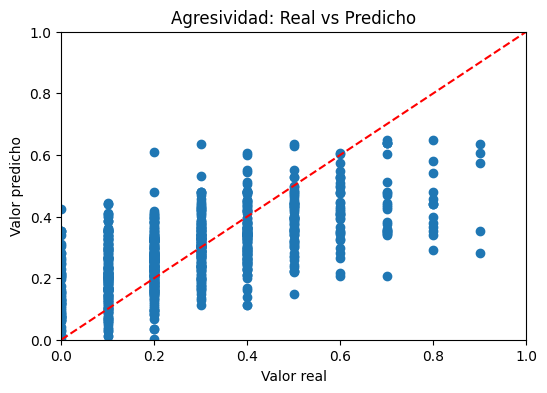

In [15]:
y_real = df['agresividad']
y_pred = modelos['agresividad'].predict(X)

plt.figure(figsize=(6,4))
plt.scatter(y_real, y_pred)
plt.plot([0,1], [0,1], 'r--')
plt.xlabel('Valor real')
plt.ylabel('Valor predicho')
plt.title('Agresividad: Real vs Predicho')
plt.xlim(0,1)
plt.ylim(0,1)
plt.show()

### Codigo de bert

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.optim import AdamW  # ← AdamW ahora está aquí
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import warnings
warnings.filterwarnings('ignore')

print("✅ Todas las librerías importadas correctamente")
print(f"PyTorch version: {torch.__version__}")

c:\Users\ivank\OneDrive\Escritorio\Final\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Todas las librerías importadas correctamente
PyTorch version: 2.11.0+cpu


In [16]:
df = pd.read_csv('Hola.txt', sep=',')

In [17]:
df

,id,frase,agresividad,manipulacion,sarcasmo
0,1,es que yo soy diferente al resto de los hombres,0.2,0.7,0.1
1,2,Es que a mi nadie me da pelota yo siempre soy ...,0.2,0.9,0.1
2,3,todo lo malo que le pasa es tu culpa,0.9,0.8,0.0
3,4,¿Le estás enviando mensajes a esa chica coquet...,0.3,0.6,0.2
4,5,¿Qué? ¿No puedo hablar con mis amigos?!,0.7,0.5,0.4
...,...,...,...,...,...
842,843,"pero bueno, supongo que así quedó",0.0,0.2,0.1
843,844,igual suerte con lo tuyo,0.0,0.1,0.1
844,845,"espero que te vaya bien, en serio",0.0,0.1,0.1
845,846,yo ya no voy a meterme más,0.0,0.2,0.1


In [18]:
df = df.drop(columns= "id")

In [19]:
df

,frase,agresividad,manipulacion,sarcasmo
0,es que yo soy diferente al resto de los hombres,0.2,0.7,0.1
1,Es que a mi nadie me da pelota yo siempre soy ...,0.2,0.9,0.1
2,todo lo malo que le pasa es tu culpa,0.9,0.8,0.0
3,¿Le estás enviando mensajes a esa chica coquet...,0.3,0.6,0.2
4,¿Qué? ¿No puedo hablar con mis amigos?!,0.7,0.5,0.4
...,...,...,...,...
842,"pero bueno, supongo que así quedó",0.0,0.2,0.1
843,igual suerte con lo tuyo,0.0,0.1,0.1
844,"espero que te vaya bien, en serio",0.0,0.1,0.1
845,yo ya no voy a meterme más,0.0,0.2,0.1


In [20]:
df.to_csv('Data.csv', index=False)


In [5]:
# Convertir a listas para evitar problemas con numpy/pyarrow
frases = df['frase'].tolist()  # Importante: .tolist()
etiquetas = df[['agresividad', 'manipulacion', 'sarcasmo']].values.tolist()  # .tolist()

# Dividir en train/test
X_train, X_test, y_train, y_test = train_test_split(
    frases,  # Ahora es lista, no Serie de pandas
    etiquetas,  # Ahora es lista, no numpy array
    test_size=0.2,
    random_state=42
)

print(f"✅ Train: {len(X_train)} frases, Test: {len(X_test)} frases")
print(f"Ejemplo de frase de entrenamiento: {X_train[0]}")

✅ Train: 677 frases, Test: 170 frases
Ejemplo de frase de entrenamiento: No voy a seguir justificando lo que duele.


In [6]:
# Detectar si hay GPU disponible
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Usando dispositivo: {device}")
if device.type == 'cpu':
    print("⚠️ Estás usando CPU - el entrenamiento será más lento")

✅ Usando dispositivo: cpu
⚠️ Estás usando CPU - el entrenamiento será más lento


In [7]:
# Modelo BERT en español
model_name = "dccuchile/bert-base-spanish-wwm-uncased"

print("🔄 Cargando modelo BERT español...")
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3,
    problem_type="regression"
)
model.to(device)
print("✅ Modelo cargado exitosamente")

🔄 Cargando modelo BERT español...


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 43818.10it/s]
BertForSequenceClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
classifier.bias                            | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 

Notes:
- UNEXPE

✅ Modelo cargado exitosamente


In [8]:
class FraseDataset(Dataset):
    def __init__(self, frases, etiquetas, tokenizer, max_len=128):
        self.frases = frases
        self.etiquetas = etiquetas
        self.tokenizer = tokenizer
        self.max_len = max_len
        
    def __len__(self):
        return len(self.frases)
    
    def __getitem__(self, idx):
        frase = str(self.frases[idx])
        etiqueta = self.etiquetas[idx]
        
        # Tokenizar la frase
        encoding = self.tokenizer(
            frase,
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt'
        )
        
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(etiqueta, dtype=torch.float32)
        }

# Crear datasets
train_dataset = FraseDataset(X_train, y_train, tokenizer)
test_dataset = FraseDataset(X_test, y_test, tokenizer)

print(f"✅ Dataset de entrenamiento: {len(train_dataset)} muestras")
print(f"✅ Dataset de prueba: {len(test_dataset)} muestras")

✅ Dataset de entrenamiento: 677 muestras
✅ Dataset de prueba: 170 muestras


In [9]:
# Parámetros
BATCH_SIZE = 2
EPOCHS = 30
LEARNING_RATE = 2e-5

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

# Optimizador (AdamW ahora desde torch.optim)
optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)

print("🚀 Comenzando entrenamiento...")
print("="*50)

# Entrenamiento
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    
    for batch in train_loader:
        # Mover datos al dispositivo
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        
        # Forward pass
        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    # Mostrar progreso cada 5 épocas
    if (epoch + 1) % 5 == 0:
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for batch in test_loader:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)
                outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
                val_loss += outputs.loss.item()
        
        avg_train_loss = total_loss / len(train_loader)
        avg_val_loss = val_loss / len(test_loader)
        print(f"Época {epoch+1:2d}/{EPOCHS} - Train Loss: {avg_train_loss:.4f} - Val Loss: {avg_val_loss:.4f}")

print("✅ Entrenamiento completado!")

🚀 Comenzando entrenamiento...


KeyboardInterrupt: 

In [ ]:
def predecir_frase(frase, model, tokenizer, device):
    """Predice las 3 variables para una frase"""
    model.eval()
    
    # Tokenizar
    encoding = tokenizer(
        frase,
        truncation=True,
        padding='max_length',
        max_length=128,
        return_tensors='pt'
    )
    
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)
    
    # Predecir
    with torch.no_grad():
        outputs = model(input_ids, attention_mask=attention_mask)
        logits = outputs.logits.cpu().numpy()[0]
        # Aplicar sigmoid para valores entre 0 y 1
        predictions = 1 / (1 + np.exp(-logits))
    
    return {
        'agresividad': round(float(predictions[0]), 3),
        'manipulacion': round(float(predictions[1]), 3),
        'sarcasmo': round(float(predictions[2]), 3)
    }

# Probar con ejemplos
print("\n" + "="*60)
print("PREDICCIONES DEL MODELO")
print("="*60)

frases_prueba = [
    "Eres un inútil, todo lo haces mal",
    "Te quiero mucho, eres especial",
    "Claro, seguro que tienes razón (guiño guiño)",
    "Si no haces lo que te digo, te arrepentirás",
    "Qué inteligente eres..."
]

for frase in frases_prueba:
    resultado = predecir_frase(frase, model, tokenizer, device)
    print(f"\n📝 Frase: {frase}")
    print(f"   😠 Agresividad: {resultado['agresividad']}")
    print(f"   🎭 Manipulación: {resultado['manipulacion']}")
    print(f"   😏 Sarcasmo: {resultado['sarcasmo']}")

### Gpu

In [10]:
import torch
print(f"¿GPU disponible? {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memoria GPU: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("⚠️ No hay GPU, se usará CPU (más lento)")

¿GPU disponible? False
⚠️ No hay GPU, se usará CPU (más lento)


In [13]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.optim import AdamW  # ← CAMBIADO: AdamW desde torch.optim
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import get_linear_schedule_with_warmup
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import warnings
import time



In [14]:
warnings.filterwarnings('ignore')

print("="*70)
print("🎯 MODELO BERT PARA DETECCIÓN DE AGRESIVIDAD, MANIPULACIÓN Y SARCASMO")
print("="*70)

🎯 MODELO BERT PARA DETECCIÓN DE AGRESIVIDAD, MANIPULACIÓN Y SARCASMO


In [15]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\n✅ Dispositivo: {device}")
if device.type == 'cuda':
    print(f"✅ GPU: {torch.cuda.get_device_name(0)}")
    print(f"✅ Memoria GPU: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    torch.cuda.empty_cache()


✅ Dispositivo: cpu


In [21]:
CSV_PATH = 'Data.csv'

try:
    df = pd.read_csv(CSV_PATH)
    print(f"\n📊 CSV cargado exitosamente!")
    print(f"✅ Total de frases: {len(df)}")
    print(f"📋 Columnas encontradas: {df.columns.tolist()}")
    
    # Verificar columnas necesarias
    columnas_necesarias = ['frase', 'agresividad', 'manipulacion', 'sarcasmo']
    for col in columnas_necesarias:
        if col not in df.columns:
            raise ValueError(f"❌ Falta la columna '{col}' en tu CSV")
    
    print(f"✅ Todas las columnas necesarias están presentes")
    
except FileNotFoundError:
    print(f"❌ No se encontró el archivo: {CSV_PATH}")
    print("Por favor, verifica la ruta del archivo")
    print("\n📝 Formato esperado del CSV:")
    print("frase,agresividad,manipulacion,sarcasmo")
    print("es que yo soy diferente,0.2,0.7,0.1")
    print("todo lo malo es tu culpa,0.9,0.8,0.0")
    exit()

print("\n🔍 Primeras 5 filas del CSV:")
print(df.head())


📊 CSV cargado exitosamente!
✅ Total de frases: 847
📋 Columnas encontradas: ['frase', 'agresividad', 'manipulacion', 'sarcasmo']
✅ Todas las columnas necesarias están presentes

🔍 Primeras 5 filas del CSV:
                                               frase  agresividad  \
0    es que yo soy diferente al resto de los hombres          0.2   
1  Es que a mi nadie me da pelota yo siempre soy ...          0.2   
2               todo lo malo que le pasa es tu culpa          0.9   
3  ¿Le estás enviando mensajes a esa chica coquet...          0.3   
4            ¿Qué? ¿No puedo hablar con mis amigos?!          0.7   

   manipulacion  sarcasmo  
0           0.7       0.1  
1           0.9       0.1  
2           0.8       0.0  
3           0.6       0.2  
4           0.5       0.4  


In [22]:
print("\n🔄 Preparando datos...")

def limpiar_texto(texto):
    """Limpieza básica de texto"""
    if pd.isna(texto):
        return ""
    texto = str(texto).lower().strip()
    texto = ''.join(char for char in texto if char.isalnum() or char in ' .,;!?¡¿')
    return texto

df['frase_limpia'] = df['frase'].apply(limpiar_texto)

# Convertir a listas
frases = df['frase_limpia'].tolist()
etiquetas = df[['agresividad', 'manipulacion', 'sarcasmo']].values.tolist()

# División de datos
X_train, X_temp, y_train, y_temp = train_test_split(
    frases, etiquetas, 
    test_size=0.3,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, 
    test_size=0.5,
    random_state=42
)

print(f"\n✅ División de datos:")
print(f"   Entrenamiento: {len(X_train)} frases ({len(X_train)/len(frases)*100:.1f}%)")
print(f"   Validación: {len(X_val)} frases ({len(X_val)/len(frases)*100:.1f}%)")
print(f"   Prueba: {len(X_test)} frases ({len(X_test)/len(frases)*100:.1f}%)")


🔄 Preparando datos...

✅ División de datos:
   Entrenamiento: 592 frases (69.9%)
   Validación: 127 frases (15.0%)
   Prueba: 128 frases (15.1%)


In [23]:
BATCH_SIZE = 16 if device.type == 'cuda' else 8
EPOCHS = 10
MAX_LEN = 128
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01
WARMUP_STEPS = 100

print(f"\n⚙️ Configuración del modelo:")
print(f"   Batch size: {BATCH_SIZE}")
print(f"   Épocas: {EPOCHS}")
print(f"   Max length: {MAX_LEN}")
print(f"   Learning rate: {LEARNING_RATE}")

# Cargar modelo BERT
print("\n🔄 Cargando modelo BERT...")
model_name = "dccuchile/bert-base-spanish-wwm-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3,
    problem_type="regression"
)

model = model.to(device)
print(f"✅ Modelo cargado en {device}")



⚙️ Configuración del modelo:
   Batch size: 8
   Épocas: 10
   Max length: 128
   Learning rate: 2e-05

🔄 Cargando modelo BERT...


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 30671.04it/s]
BertForSequenceClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
classifier.bias                            | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 

Notes:
- UNEXPE

✅ Modelo cargado en cpu


In [ ]:
class FraseDataset(Dataset):
    def __init__(self, frases, etiquetas, tokenizer, max_len):
        self.frases = frases
        self.etiquetas = etiquetas
        self.tokenizer = tokenizer
        self.max_len = max_len
    
    def __len__(self):
        return len(self.frases)
    
    def __getitem__(self, idx):
        frase = str(self.frases[idx])
        etiqueta = self.etiquetas[idx]
        
        encoding = self.tokenizer(
            frase,
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt'
        )
        
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(etiqueta, dtype=torch.float32)
        }

# Crear datasets
train_dataset = FraseDataset(X_train, y_train, tokenizer, MAX_LEN)
val_dataset = FraseDataset(X_val, y_val, tokenizer, MAX_LEN)
test_dataset = FraseDataset(X_test, y_test, tokenizer, MAX_LEN)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

In [25]:
# Optimizador usando AdamW de torch.optim
optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

# Scheduler
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=WARMUP_STEPS,
    num_training_steps=total_steps
)

# Early stopping
best_val_loss = float('inf')
patience = 3
patience_counter = 0

train_losses = []
val_losses = []

print("\n" + "="*70)
print("🚀 COMIENZA EL ENTRENAMIENTO")
print("="*70)

start_time = time.time()

for epoch in range(EPOCHS):
    # Entrenamiento
    model.train()
    total_train_loss = 0
    
    for batch_idx, batch in enumerate(train_loader):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        
        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        
        total_train_loss += loss.item()
        
        if (batch_idx + 1) % 50 == 0:
            print(f"  Época {epoch+1}/{EPOCHS} - Batch {batch_idx+1}/{len(train_loader)} - Loss: {loss.item():.4f}")
    
    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    # Validación
    model.eval()
    total_val_loss = 0
    
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            
            outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
            total_val_loss += outputs.loss.item()
    
    avg_val_loss = total_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    
    elapsed_time = time.time() - start_time
    print(f"\n📊 Época {epoch+1}/{EPOCHS}")
    print(f"   Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
    print(f"   Tiempo: {elapsed_time/60:.1f} minutos")
    
    # Early stopping
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        torch.save(model.state_dict(), 'mejor_modelo_bert.pth')
        print(f"   ✨ Mejor modelo guardado (loss: {best_val_loss:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\n🛑 Early stopping en época {epoch+1}")
            break

total_time = time.time() - start_time
print(f"\n✅ Entrenamiento completado en {total_time/60:.1f} minutos")


🚀 COMIENZA EL ENTRENAMIENTO
  Época 1/10 - Batch 50/74 - Loss: 0.0383

📊 Época 1/10
   Train Loss: 0.0799 | Val Loss: 0.0285
   Tiempo: 3.2 minutos
   ✨ Mejor modelo guardado (loss: 0.0285)
  Época 2/10 - Batch 50/74 - Loss: 0.0183

📊 Época 2/10
   Train Loss: 0.0217 | Val Loss: 0.0196
   Tiempo: 6.3 minutos
   ✨ Mejor modelo guardado (loss: 0.0196)
  Época 3/10 - Batch 50/74 - Loss: 0.0223

📊 Época 3/10
   Train Loss: 0.0138 | Val Loss: 0.0187
   Tiempo: 9.4 minutos
   ✨ Mejor modelo guardado (loss: 0.0187)
  Época 4/10 - Batch 50/74 - Loss: 0.0101

📊 Época 4/10
   Train Loss: 0.0111 | Val Loss: 0.0171
   Tiempo: 12.5 minutos
   ✨ Mejor modelo guardado (loss: 0.0171)
  Época 5/10 - Batch 50/74 - Loss: 0.0075

📊 Época 5/10
   Train Loss: 0.0084 | Val Loss: 0.0200
   Tiempo: 15.6 minutos
  Época 6/10 - Batch 50/74 - Loss: 0.0051

📊 Época 6/10
   Train Loss: 0.0074 | Val Loss: 0.0166
   Tiempo: 18.7 minutos
   ✨ Mejor modelo guardado (loss: 0.0166)
  Época 7/10 - Batch 50/74 - Loss: 0.0

In [26]:
# Cargar el mejor modelo
model.load_state_dict(torch.load('mejor_modelo_bert.pth'))

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        
        outputs = model(input_ids, attention_mask=attention_mask)
        predictions = torch.sigmoid(outputs.logits).cpu().numpy()
        
        all_preds.extend(predictions)
        all_labels.extend(batch['labels'].cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

print("\n" + "="*70)
print("📊 RESULTADOS EN CONJUNTO DE PRUEBA")
print("="*70)

for idx, var in enumerate(['Agresividad', 'Manipulación', 'Sarcasmo']):
    mse = mean_squared_error(all_labels[:, idx], all_preds[:, idx])
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(all_labels[:, idx], all_preds[:, idx])
    r2 = r2_score(all_labels[:, idx], all_preds[:, idx])
    
    print(f"\n🎯 {var}:")
    print(f"   ✅ MSE: {mse:.4f}")
    print(f"   ✅ RMSE: {rmse:.4f}")
    print(f"   ✅ MAE: {mae:.4f}")
    print(f"   ✅ R²: {r2:.4f}")


📊 RESULTADOS EN CONJUNTO DE PRUEBA

🎯 Agresividad:
   ✅ MSE: 0.1100
   ✅ RMSE: 0.3317
   ✅ MAE: 0.3003
   ✅ R²: -2.6858

🎯 Manipulación:
   ✅ MSE: 0.0329
   ✅ RMSE: 0.1813
   ✅ MAE: 0.1449
   ✅ R²: -0.4874

🎯 Sarcasmo:
   ✅ MSE: 0.1187
   ✅ RMSE: 0.3446
   ✅ MAE: 0.3306
   ✅ R²: -8.0296


In [27]:
def predecir_frase(frase):
    """Predice las 3 variables para una nueva frase"""
    model.eval()
    
    frase = limpiar_texto(frase)
    
    encoding = tokenizer(
        frase,
        truncation=True,
        padding='max_length',
        max_length=MAX_LEN,
        return_tensors='pt'
    )
    
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)
    
    with torch.no_grad():
        outputs = model(input_ids, attention_mask=attention_mask)
        predictions = torch.sigmoid(outputs.logits).cpu().numpy()[0]
    
    return {
        'agresividad': round(float(predictions[0]), 3),
        'manipulacion': round(float(predictions[1]), 3),
        'sarcasmo': round(float(predictions[2]), 3)
    }


In [28]:
print("\n" + "="*70)
print("🧪 PRUEBAS DEL MODELO")
print("="*70)

frases_prueba = [
    "Eres un inútil, todo lo haces mal",
    "Te quiero mucho, eres muy especial",
    "Claro, seguro que tienes razón (guiño guiño)",
    "Si no haces lo que te digo, te vas a arrepentir",
    "Qué inteligente eres, en serio..."
]

for frase in frases_prueba:
    resultado = predecir_frase(frase)
    print(f"\n📝 '{frase}'")
    print(f"   😠 Agresividad: {resultado['agresividad']}")
    print(f"   🎭 Manipulación: {resultado['manipulacion']}")
    print(f"   😏 Sarcasmo: {resultado['sarcasmo']}")


🧪 PRUEBAS DEL MODELO

📝 'Eres un inútil, todo lo haces mal'
   😠 Agresividad: 0.634
   🎭 Manipulación: 0.647
   😏 Sarcasmo: 0.536

📝 'Te quiero mucho, eres muy especial'
   😠 Agresividad: 0.584
   🎭 Manipulación: 0.655
   😏 Sarcasmo: 0.512

📝 'Claro, seguro que tienes razón (guiño guiño)'
   😠 Agresividad: 0.588
   🎭 Manipulación: 0.602
   😏 Sarcasmo: 0.607

📝 'Si no haces lo que te digo, te vas a arrepentir'
   😠 Agresividad: 0.633
   🎭 Manipulación: 0.63
   😏 Sarcasmo: 0.517

📝 'Qué inteligente eres, en serio...'
   😠 Agresividad: 0.563
   🎭 Manipulación: 0.61
   😏 Sarcasmo: 0.587


In [29]:
model_save_path = './modelo_bert_850_frases'
tokenizer_save_path = './tokenizer_bert_850_frases'

model.save_pretrained(model_save_path)
tokenizer.save_pretrained(tokenizer_save_path)

print("\n" + "="*70)
print("💾 MODELO GUARDADO")
print("="*70)
print(f"✅ Modelo guardado en: {model_save_path}")
print(f"✅ Tokenizer guardado en: {tokenizer_save_path}")

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.82it/s]


💾 MODELO GUARDADO
✅ Modelo guardado en: ./modelo_bert_850_frases
✅ Tokenizer guardado en: ./tokenizer_bert_850_frases


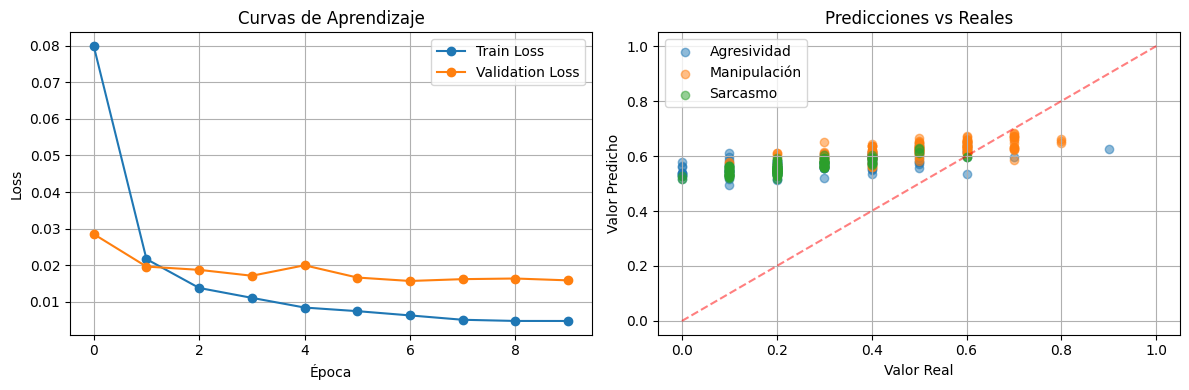


🎉 ¡PROCESO COMPLETADO EXITOSAMENTE!


In [30]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss', marker='o')
plt.plot(val_losses, label='Validation Loss', marker='o')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.title('Curvas de Aprendizaje')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
for idx, var in enumerate(['Agresividad', 'Manipulación', 'Sarcasmo']):
    plt.scatter(all_labels[:, idx], all_preds[:, idx], alpha=0.5, label=var)
plt.plot([0, 1], [0, 1], 'r--', alpha=0.5)
plt.xlabel('Valor Real')
plt.ylabel('Valor Predicho')
plt.title('Predicciones vs Reales')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print("\n🎉 ¡PROCESO COMPLETADO EXITOSAMENTE!")

In [31]:
import torch
import joblib
import os
from datetime import datetime

print("="*60)
print("💾 GUARDANDO MODELO PARA PRODUCCIÓN")
print("="*60)

# Crear carpeta para el modelo
modelo_dir = './modelo_produccion'
os.makedirs(modelo_dir, exist_ok=True)

# 1. Guardar modelo BERT en formato Hugging Face
model.save_pretrained(f'{modelo_dir}/bert_model')
tokenizer.save_pretrained(f'{modelo_dir}/bert_model')

# 2. Guardar configuración adicional
config = {
    'max_length': MAX_LEN,
    'model_type': 'bert-base-spanish',
    'fecha_entrenamiento': datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    'num_frases_entrenamiento': len(X_train),
    'version': '1.0.0'
}

import json
with open(f'{modelo_dir}/config.json', 'w', encoding='utf-8') as f:
    json.dump(config, f, indent=2, ensure_ascii=False)

print(f"✅ Modelo guardado en: {modelo_dir}")
print(f"📁 Archivos generados:")
for file in os.listdir(modelo_dir):
    print(f"   - {file}")

💾 GUARDANDO MODELO PARA PRODUCCIÓN


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.16it/s]

✅ Modelo guardado en: ./modelo_produccion
📁 Archivos generados:
   - bert_model
   - config.json


In [ ]:
def limpiar_texto(texto):
    texto = str(texto).lower().strip()
    # Mantener letras, números, espacios y puntuación básica
    texto = ''.join(char for char in texto 
                    if char.isalnum() or char in ' .,;!?¡¿')
    return texto